  MODÈLE DÉTECTION D'ANOMALIES : ABSENCE SUSPECTE

📊 Dataset chargé : 740 lignes, 21 colonnes
   ✅ Nettoyage terminé : 725 lignes restantes

  ÉTAPE 1 : FEATURE ENGINEERING
   ✅ Feature engineering terminé

  ÉTAPE 2 : ANALYSE INITIALE DES VARIABLES (SHAP)
   🔄 Entraînement du modèle exploratoire...
   🧠 Calcul des valeurs SHAP (Cela peut prendre quelques secondes)...

   Génération du Graphique SHAP (Importance des variables initiales)...


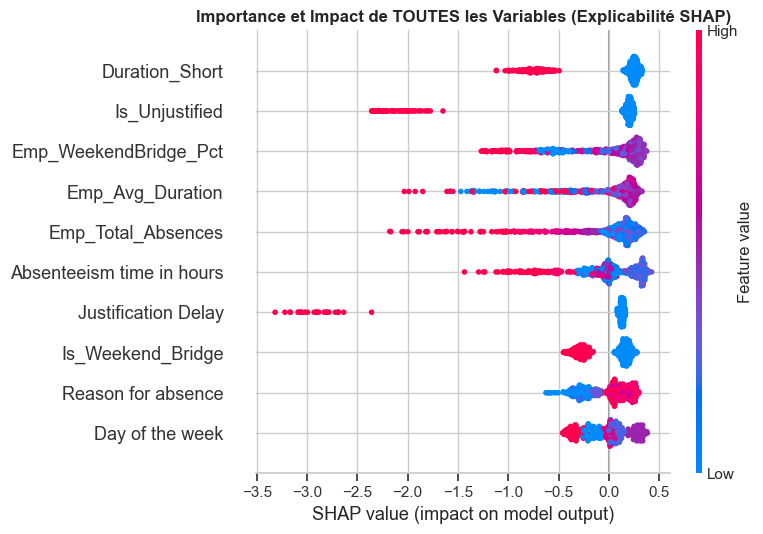


  ÉTAPE 3 : FILTRAGE ET ENTRAÎNEMENT DU MODÈLE FINAL
   ✅ Scaling final terminé sur 6 features optimisées.
   🔄 Entraînement Modèle Final : Isolation Forest...
   🔄 Entraînement Modèle 2 : Local Outlier Factor (LOF)...

  ÉTAPE 3.1 : ÉVALUATION DE LA ROBUSTESSE DU MODÈLE NON-SUPERVISÉ

   🔄 Calcul de la stabilité des détections (10 itérations)...
   🔹 Stabilité des clusters (ARI)  : 0.9373 (1.0 = Parfaitement stable, 0.0 = Aléatoire)
      -> Excellent : Les anomalies détectées sont très stables.

📋 Résultats de la Détection Croisée Finale :
Absence_Status
Legitime    713
Suspecte     12
Name: count, dtype: int64

  ÉTAPE 4 : PROFIL DES CLUSTERS ET RAPPORTS D'ANOMALIES

🔍 PROFIL DES 2 CLUSTERS DÉTECTÉS PAR L'IA (Légitime vs Suspecte) :
Le modèle a réparti les données en 2 groupes principaux :

   🟢 CLUSTER : LEGITIME (713 absences)
      - Justification Delay       : 0.03
      - Is_Unjustified            : 0.08
      - Duration_Short            : 0.25
      - Emp_Total_Absences      

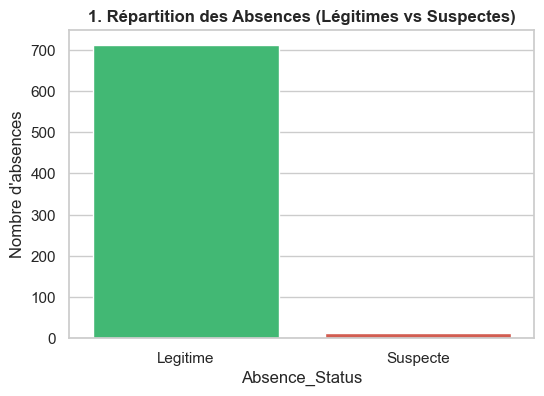

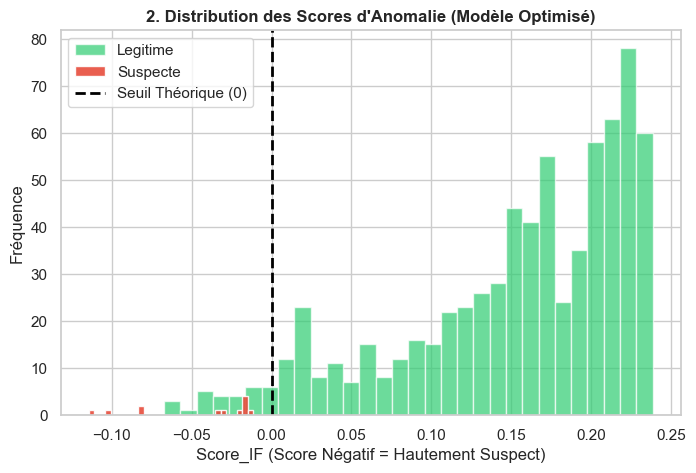

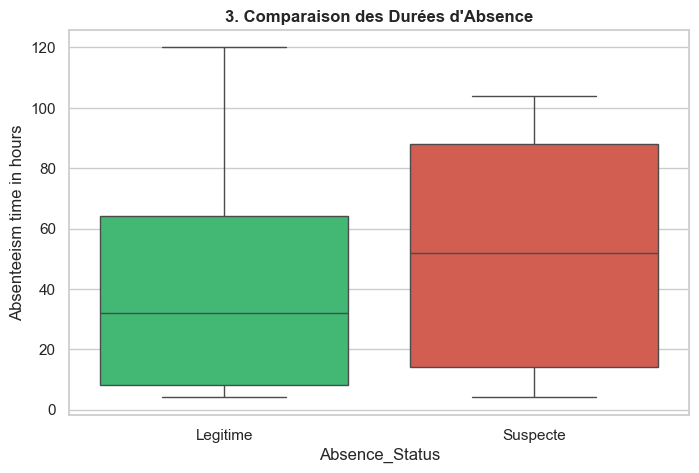


   Génération de la projection PCA 2D...


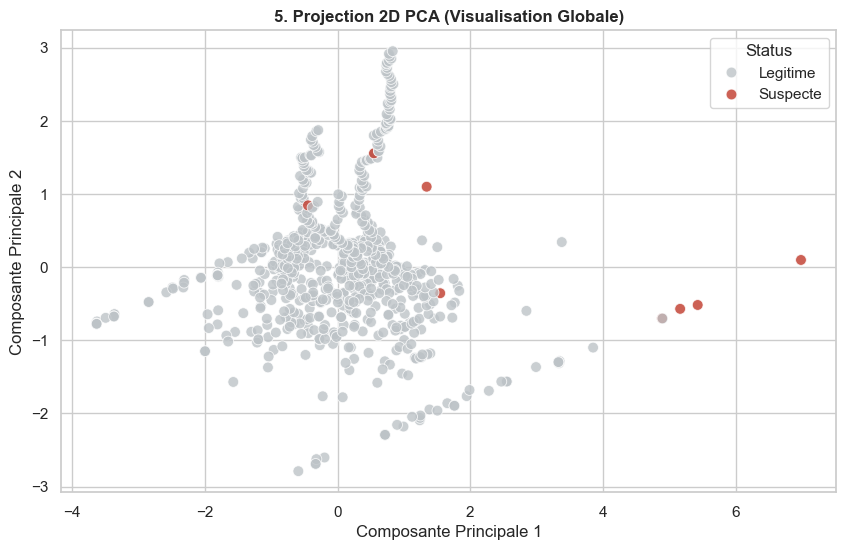

   Génération de la projection t-SNE pour une meilleure vue des clusters...


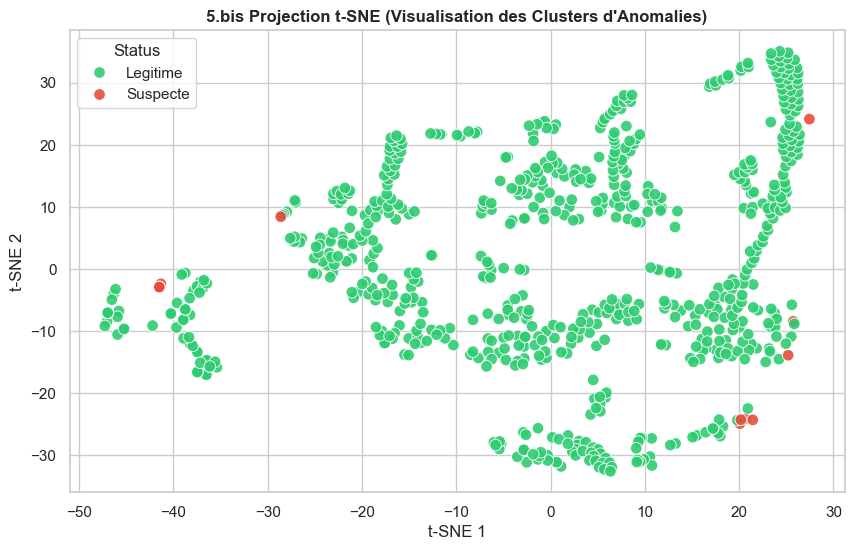

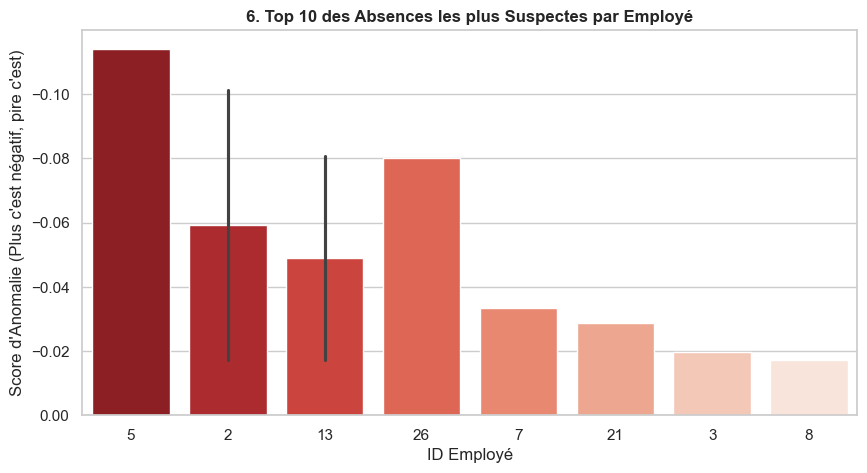


  ÉTAPE 6 : SAUVEGARDE DES ARTEFACTS POUR LE DÉPLOIEMENT
   ✅ Modèle Isolation Forest   → C:\Users\Malek\Downloads\models\best_suspicious_model.pkl
   ✅ Modèle LOF                → C:\Users\Malek\Downloads\models\lof_suspicious_model.pkl
   ✅ Scaler                    → C:\Users\Malek\Downloads\models\scaler_suspicious.pkl
   ✅ Features utilisées        → C:\Users\Malek\Downloads\models\suspicious_features.pkl
   ✅ Base de données finale exportée ici : C:\Users\Malek\Downloads\models\dataset_evalue_isolation_forest.csv

  ✅ PIPELINE TERMINÉ AVEC SUCCÈS !


In [6]:
"""
=============================================================================
 MODÈLE ABSENCE SUSPECTE / ABUSIVE - HR Analytics (Version Unsupervised)
 Projet PFE : Plateforme Intelligente de Gestion RH & Analytics
=============================================================================
 Ce script entraîne un Modèle de Détection d'Anomalies (Isolation Forest).

 LOGIQUE :
   Au lieu de dicter à l'algorithme ce qui est suspect via des règles 
   strictes (ce qui crée un biais), nous laissons l'IA analyser le rythme 
   "normal" de l'entreprise. 
   Les absences qui dévient mathématiquement de ce comportement normal 
   sont isolées et flaggées comme "Suspectes".

 INPUT API : Une ou plusieurs absences individuelles
 OUTPUT    : Absence_Status ∈ {Legitime, Suspecte} + Score d'anomalie
=============================================================================
"""

import pandas as pd
import numpy as np
import joblib
import os
import warnings

# --- Machine Learning ---
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
import shap

# --- Visualisations ---
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid") # Thème esthétique pour les graphiques

# ============================================================================
# 1. CHARGEMENT & NETTOYAGE
# ============================================================================
print("=" * 70)
print("  MODÈLE DÉTECTION D'ANOMALIES : ABSENCE SUSPECTE")
print("=" * 70)

# --- CHEMINS LOCAUX MIS À JOUR ---
DATA_PATH = r"C:\Users\Malek\Desktop\PFE-Integration\dados_tunisie.csv"
MODEL_DIR = r"C:\Users\Malek\Downloads\models"
EXPORT_PATH = os.path.join(MODEL_DIR, 'dataset_evalue_isolation_forest.csv')

os.makedirs(MODEL_DIR, exist_ok=True)

try:
    df = pd.read_csv(DATA_PATH, sep=';')
    print(f"\n📊 Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
except FileNotFoundError:
    print(f"❌ Erreur : Fichier introuvable à l'emplacement {DATA_PATH}.")
    print("Veuillez vérifier le chemin d'accès (DATA_PATH) avant de lancer le script.")
    exit()

# Nettoyage standard
df = df[df['Month of absence'] > 0].copy()
df = df.drop_duplicates()
mask_fake = (df['ID'] == 29) & (df['Age'] == 28) & (df['Education'] == 1)
df = df[~mask_fake].copy()
mask_incoh_1 = (df['Reason for absence'] == 1) & (df['Justification Delay'] == 1)
mask_incoh_2 = (df['Reason for absence'] == 8) & (df['Justification Delay'] == 1)
df = df[~(mask_incoh_1 | mask_incoh_2)].copy()
df = df.reset_index(drop=True)
print(f"   ✅ Nettoyage terminé : {len(df)} lignes restantes")


# ============================================================================
# 2. FEATURE ENGINEERING (Sans fuite de données)
# ============================================================================
print("\n" + "=" * 70)
print("  ÉTAPE 1 : FEATURE ENGINEERING")
print("=" * 70)

SERIOUS_MEDICAL   = [2, 4, 9, 10]
CONVENIENT_REASONS= [1, 3, 7]
WEEKEND_DAYS      = [2, 6]

# --- Features historiques par employé ---
# Trier dans un ordre chronologique plus fiable
df = df.sort_values(
    by=['ID', 'Month of absence', 'Day of the week']
).reset_index(drop=True)

# Variables temporaires pour les historiques
df['Temp_WeekendBridge'] = df['Day of the week'].isin(WEEKEND_DAYS).astype(int)
df['Temp_Medical'] = df['Reason for absence'].isin(SERIOUS_MEDICAL).astype(int)
df['Temp_Unjustified'] = (df['Reason for absence'] == 8).astype(int)

# Nombre d'absences AVANT l'absence actuelle
df['Emp_Total_Absences'] = df.groupby('ID').cumcount()

# Moyenne des absences précédentes uniquement
df['Emp_Avg_Duration'] = (
    df.groupby('ID')['Absenteeism time in hours']
      .transform(lambda s: s.shift(1).expanding().mean())
)

# Pourcentage de ponts lundi/vendredi AVANT l'absence actuelle
df['Emp_WeekendBridge_Pct'] = (
    df.groupby('ID')['Temp_WeekendBridge']
      .transform(lambda s: s.shift(1).expanding().mean())
)

# Pourcentage d'absences médicales précédentes
df['Emp_Medical_Pct'] = (
    df.groupby('ID')['Temp_Medical']
      .transform(lambda s: s.shift(1).expanding().mean())
)

# Nombre d'absences injustifiées précédentes
df['Emp_Unjustified_Count'] = (
    df.groupby('ID')['Temp_Unjustified']
      .transform(lambda s: s.shift(1).cumsum())
)

# Premier historique absent : valeurs neutres
df['Emp_Avg_Duration'] = df['Emp_Avg_Duration'].fillna(
    df['Absenteeism time in hours'].median()
)

df['Emp_WeekendBridge_Pct'] = df['Emp_WeekendBridge_Pct'].fillna(0)
df['Emp_Medical_Pct'] = df['Emp_Medical_Pct'].fillna(0)
df['Emp_Unjustified_Count'] = df['Emp_Unjustified_Count'].fillna(0)

# Supprimer les colonnes temporaires
df.drop(
    columns=['Temp_WeekendBridge', 'Temp_Medical', 'Temp_Unjustified'],
    inplace=True
)

# --- Features binaires du jour ---
df['Is_Monday']  = (df['Day of the week'] == 2).astype(int)
df['Is_Friday']  = (df['Day of the week'] == 6).astype(int)
df['Is_Weekend_Bridge'] = df['Is_Monday'] | df['Is_Friday']

# --- Features binaires de la raison ---
df['Is_Serious_Medical'] = df['Reason for absence'].isin(SERIOUS_MEDICAL).astype(int)
df['Is_Unjustified']     = (df['Reason for absence'] == 8).astype(int)
df['Is_Convenient']      = df['Reason for absence'].isin(CONVENIENT_REASONS).astype(int)

# --- Durée catégorisée ---
df['Duration_Short']  = (df['Absenteeism time in hours'] <= 8).astype(int)
df['Duration_Medium'] = ((df['Absenteeism time in hours'] > 8)  & (df['Absenteeism time in hours'] <= 40)).astype(int)
df['Duration_Long']   = (df['Absenteeism time in hours'] > 40).astype(int)

print(f"   ✅ Feature engineering terminé")

# ============================================================================
# 3. ANALYSE INITIALE DES FEATURES (SHAP EXPLORATOIRE)
# ============================================================================
print("\n" + "=" * 70)
print("  ÉTAPE 2 : ANALYSE INITIALE DES VARIABLES (SHAP)")
print("=" * 70)

# Sélection initiale de toutes les features possibles (avant analyse)
initial_features = [
    'Justification Delay', 'Day of the week', 'Is_Weekend_Bridge',
    'Reason for absence', 'Is_Unjustified', 'Absenteeism time in hours', 
    'Duration_Short', 'Emp_Total_Absences', 'Emp_WeekendBridge_Pct', 'Emp_Avg_Duration'
]

# Entraînement rapide d'un modèle temporaire juste pour la visualisation SHAP
X_initial = df[initial_features].fillna(0).astype(float)
scaler_initial = RobustScaler()
X_scaled_initial = scaler_initial.fit_transform(X_initial)

print("   🔄 Entraînement du modèle exploratoire...")
iso_forest_initial = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
iso_forest_initial.fit(X_scaled_initial)

print("   🧠 Calcul des valeurs SHAP (Cela peut prendre quelques secondes)...")
explainer_initial = shap.TreeExplainer(iso_forest_initial)
shap_values_initial = explainer_initial.shap_values(X_scaled_initial)

print("\n   Génération du Graphique SHAP (Importance des variables initiales)...")
plt.figure(figsize=(10, 6))
plt.title("Importance et Impact de TOUTES les Variables (Explicabilité SHAP)", fontweight='bold')
shap.summary_plot(shap_values_initial, X_initial, feature_names=initial_features, show=False)
plt.show()

# ============================================================================
# 4. FILTRAGE DES DONNÉES ET ENTRAÎNEMENT FINAL (ENSEMBLING)
# ============================================================================
print("\n" + "=" * 70)
print("  ÉTAPE 3 : FILTRAGE ET ENTRAÎNEMENT DU MODÈLE FINAL")
print("=" * 70)

# Suite à l'analyse SHAP ci-dessus, on filtre pour ne garder que les plus pertinentes :
available_features = [
    'Justification Delay', 'Is_Unjustified', 
    'Duration_Short', 'Emp_Total_Absences', 'Emp_WeekendBridge_Pct', 'Emp_Avg_Duration'
]

X = df[available_features].fillna(0).astype(float)
scaler_suspicious = RobustScaler()
X_scaled = scaler_suspicious.fit_transform(X)

print(f"   ✅ Scaling final terminé sur {X_scaled.shape[1]} features optimisées.")

CONTAMINATION_RATE = 0.05

# Modèle 1 : Isolation Forest (Modèle Final)
print("   🔄 Entraînement Modèle Final : Isolation Forest...")
iso_forest = IsolationForest(n_estimators=300, contamination=CONTAMINATION_RATE, random_state=42, n_jobs=-1)
df['Anomaly_IF'] = iso_forest.fit_predict(X_scaled)
df['Score_IF'] = iso_forest.decision_function(X_scaled)

# Modèle 2 : Local Outlier Factor (LOF)
print("   🔄 Entraînement Modèle 2 : Local Outlier Factor (LOF)...")
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION_RATE, novelty=True)
lof.fit(X_scaled)
df['Anomaly_LOF'] = lof.predict(X_scaled)

# Règle d'Ensembling : Intersection. Conserve uniquement les absences détectées par IF ET LOF.
# Méthode plus stricte, avec moins de faux positifs.
df['Absence_Status'] = 'Legitime'
df.loc[(df['Anomaly_IF'] == -1) & (df['Anomaly_LOF'] == -1), 'Absence_Status'] = 'Suspecte'

# -- Évaluation Non-Supervisée (Stabilité) --
from sklearn.metrics import adjusted_rand_score

print("\n" + "=" * 70)
print("  ÉTAPE 3.1 : ÉVALUATION DE LA ROBUSTESSE DU MODÈLE NON-SUPERVISÉ")
print("=" * 70)

# 1. Stabilité des Clusters (Isolation Forest avec différentes seeds)
print("\n   🔄 Calcul de la stabilité des détections (10 itérations)...")
stability_scores = []
base_labels = df['Anomaly_IF']

for seed in range(1, 11):
    temp_iso = IsolationForest(n_estimators=300, contamination=CONTAMINATION_RATE, random_state=seed, n_jobs=-1)
    temp_labels = temp_iso.fit_predict(X_scaled)
    stability_scores.append(adjusted_rand_score(base_labels, temp_labels))

avg_stability = np.mean(stability_scores)
print(f"   🔹 Stabilité des clusters (ARI)  : {avg_stability:.4f} (1.0 = Parfaitement stable, 0.0 = Aléatoire)")
if avg_stability > 0.9:
    print("      -> Excellent : Les anomalies détectées sont très stables.")
elif avg_stability > 0.7:
    print("      -> Bon : La détection est globalement stable.")
else:
    print("      -> Attention : Les résultats fluctuent selon la seed aléatoire.")

print("\n📋 Résultats de la Détection Croisée Finale :")
print(df['Absence_Status'].value_counts())

# ============================================================================
# 5. RAPPORTS D'ANOMALIES, EXPLICABILITÉ ET PROFIL DES CLUSTERS
# ============================================================================
print("\n" + "=" * 70)
print("  ÉTAPE 4 : PROFIL DES CLUSTERS ET RAPPORTS D'ANOMALIES")
print("=" * 70)

# --- PROFILAGE DES "CLUSTERS" (Légitime vs Suspecte) ---
print("\n🔍 PROFIL DES 2 CLUSTERS DÉTECTÉS PAR L'IA (Légitime vs Suspecte) :")
print(f"Le modèle a réparti les données en 2 groupes principaux :")

cluster_profiles = df.groupby('Absence_Status')[available_features].mean().round(2)

for status in cluster_profiles.index:
    count = len(df[df['Absence_Status'] == status])
    print(f"\n   🟢 CLUSTER : {status.upper()} ({count} absences)")
    for feature in available_features:
        val = cluster_profiles.loc[status, feature]
        print(f"      - {feature:<25} : {val}")

# Si vous voulez sous-catégoriser les anomalies, on peut appliquer KMeans sur les suspectes
suspects_df = df[df['Absence_Status'] == 'Suspecte']
if len(suspects_df) > 5:
    from sklearn.cluster import KMeans
    print("\n   🧩 SOUS-CLUSTERS DES ABSENCES SUSPECTES (K-Means) :")
    # On cherche 2 ou 3 sous-profils d'abus
    n_clusters = min(3, len(suspects_df) // 2)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    suspect_scaled = scaler_suspicious.transform(suspects_df[available_features].fillna(0).astype(float))
    suspect_labels = kmeans.fit_predict(suspect_scaled)
    
    suspects_df['Sous_Cluster'] = suspect_labels
    sub_profiles = suspects_df.groupby('Sous_Cluster')[available_features].mean().round(2)
    
    print(f"   L'IA a identifié {n_clusters} types différents d'absences suspectes :")
    for cluster_id in sub_profiles.index:
        count = len(suspects_df[suspects_df['Sous_Cluster'] == cluster_id])
        print(f"\n      🔺 Type d'abus {cluster_id + 1} ({count} cas) :")
        for feature in available_features:
            val = sub_profiles.loc[cluster_id, feature]
            print(f"         - {feature:<25} : {val}")


print("\n🚨 RAPPORTS INDIVIDUELS (TOP 3 DES PIRES ANOMALIES) :")
explainer = shap.TreeExplainer(iso_forest)
shap_values = explainer.shap_values(X_scaled)

top_suspects_idx = df[df['Absence_Status'] == 'Suspecte'].sort_values('Score_IF').head(3).index

for idx in top_suspects_idx:
    employe_id = df.loc[idx, 'ID']
    score = df.loc[idx, 'Score_IF']
    
    contributions = shap_values[idx]
    top_3_features_idx = np.argsort(np.abs(contributions))[::-1][:3]
    
    print(f"\n   👤 Employé ID : {employe_id} | Score d'Anomalie : {score:.4f}")
    print(f"   L'IA a flaggé cette absence principalement à cause de :")
    for feat_idx in top_3_features_idx:
        feature_name = available_features[feat_idx]
        feature_value = df.loc[idx, feature_name]
        print(f"      - {feature_name} = {feature_value}")

# ============================================================================
# 6. VISUALISATIONS COMPLÉMENTAIRES
# ============================================================================
print("\n" + "=" * 70)
print("  ÉTAPE 5 : GÉNÉRATION DES VISUALISATIONS GLOBALES")
print("=" * 70)

palette_colors = {'Legitime': '#2ecc71', 'Suspecte': '#e74c3c'}

# 1. Répartition des absences
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Absence_Status', palette=palette_colors)
plt.title('1. Répartition des Absences (Légitimes vs Suspectes)', fontweight='bold')
plt.ylabel('Nombre d\'absences')
plt.show()

# 2. Distribution du Score_IF
plt.figure(figsize=(8, 5))
plt.hist(df[df['Absence_Status'] == 'Legitime']['Score_IF'], bins=30, color='#2ecc71', alpha=0.7, label='Legitime')
plt.hist(df[df['Absence_Status'] == 'Suspecte']['Score_IF'], bins=30, color='#e74c3c', alpha=0.9, label='Suspecte')
plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Seuil Théorique (0)')
plt.title("2. Distribution des Scores d'Anomalie (Modèle Optimisé)", fontweight='bold')
plt.xlabel('Score_IF (Score Négatif = Hautement Suspect)')
plt.ylabel('Fréquence')
plt.legend()
plt.show()

# 3. Boxplot sur la durée
plt.figure(figsize=(8, 5))
sns.boxplot(x='Absence_Status', y='Absenteeism time in hours', data=df, palette=palette_colors)
plt.title("3. Comparaison des Durées d'Absence", fontweight='bold')
plt.show()

# 5. PCA 2D (Visualisation des anomalies dans l'espace)
print("\n   Génération de la projection PCA 2D...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['Composante Principale 1', 'Composante Principale 2'])
df_pca['Status'] = df['Absence_Status']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Composante Principale 1', y='Composante Principale 2', 
    hue='Status', palette={'Legitime': '#bdc3c7', 'Suspecte': '#c0392b'},
    data=df_pca, alpha=0.8, edgecolor='w', s=60
)
plt.title("5. Projection 2D PCA (Visualisation Globale)", fontweight='bold')
plt.show()

# 5.bis t-SNE (Visualisation Avancée des Clusters)
from sklearn.manifold import TSNE
print("   Génération de la projection t-SNE pour une meilleure vue des clusters...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
df_tsne = pd.DataFrame(X_tsne, columns=['t-SNE 1', 't-SNE 2'])
df_tsne['Status'] = df['Absence_Status']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='t-SNE 1', y='t-SNE 2', 
    hue='Status', palette={'Legitime': '#2ecc71', 'Suspecte': '#e74c3c'},
    data=df_tsne, alpha=0.9, edgecolor='w', s=70
)
plt.title("5.bis Projection t-SNE (Visualisation des Clusters d'Anomalies)", fontweight='bold')
plt.show()

# 6. Top 10 employés les plus suspects (Bar Chart)
top_10 = df[df['Absence_Status'] == 'Suspecte'].sort_values('Score_IF').head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_10['ID'].astype(str), y=top_10['Score_IF'], palette='Reds_r')
plt.title("6. Top 10 des Absences les plus Suspectes par Employé", fontweight='bold')
plt.xlabel("ID Employé")
plt.ylabel("Score d'Anomalie (Plus c'est négatif, pire c'est)")
plt.gca().invert_yaxis() # Inverser l'axe Y pour que la pire barre descende le plus bas
plt.show()



# ============================================================================
# 7. SAUVEGARDE DES ARTEFACTS
# ============================================================================
print("\n" + "=" * 70)
print("  ÉTAPE 6 : SAUVEGARDE DES ARTEFACTS POUR LE DÉPLOIEMENT")
print("=" * 70)

joblib.dump(iso_forest,         os.path.join(MODEL_DIR, 'best_suspicious_model.pkl'))
joblib.dump(lof,                os.path.join(MODEL_DIR, 'lof_suspicious_model.pkl'))
joblib.dump(scaler_suspicious,  os.path.join(MODEL_DIR, 'scaler_suspicious.pkl'))
joblib.dump(available_features, os.path.join(MODEL_DIR, 'suspicious_features.pkl'))

print(f"   ✅ Modèle Isolation Forest   → {MODEL_DIR}\\best_suspicious_model.pkl")
print(f"   ✅ Modèle LOF                → {MODEL_DIR}\\lof_suspicious_model.pkl")
print(f"   ✅ Scaler                    → {MODEL_DIR}\\scaler_suspicious.pkl")
print(f"   ✅ Features utilisées        → {MODEL_DIR}\\suspicious_features.pkl")

# Sauvegarde du dataset avec les nouveaux scores pour le Dashboard RH
df.to_csv(EXPORT_PATH, index=False, sep=';')
print(f"   ✅ Base de données finale exportée ici : {EXPORT_PATH}")

print("\n" + "=" * 70)
print("  ✅ PIPELINE TERMINÉ AVEC SUCCÈS !")
print("=" * 70)
